# Figure: LM genome-prediction performance across corpus tiers and architectures

This figure compares the masked-DNA language model (`Shorkie LM`) on a held-out test set across four training-corpus tiers (R64 yeast, 80 strains, 165 Saccharomycetales, 1342 fungi) and four architectures (Conv Small/Big, U-Net Small/Big). Each model's held-out categorical cross-entropy loss and perplexity are parsed from its evaluation log, and we additionally break perplexity down by genomic region (gene vs. intergenic). Lower loss / perplexity is better.

**Reproduces:** the LM test-set loss / perplexity comparison bar charts (model-architecture vs. corpus-tier).

**Upstream:** `scripts/03_eval/lm/lm_model_eval/` runs the LM evaluation that writes one `test_testset_perplexity_region/test_testset_perplexity_region.out` log per `lm_<dataset>_gtf_<arch>` model directory under `results.lm_eval_logs`. Those `.out` logs are the input to this notebook and are not part of the released data, so this notebook is **not** runnable end-to-end from the public release.

**Requires:** the `yeast_ml` conda env with the package installed (`pip install -e .`). No GPU needed (load-and-plot only). The LM eval `.out` logs must already exist under `results.lm_eval_logs`.

**Source script:** ported from `scripts/03_eval/lm/lm_model_eval/2_model_arch_comparison_test_eval_loss_perplexity.py` (with the file-path construction from `1_model_arch_comparison_test_eval.py`).

In [1]:
import os
from io import StringIO
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from shorkie import config

In [2]:
# Path resolution via shorkie.config -- never hardcode absolute paths.
# results.lm_eval_logs points at the LM_Johannes subtree; its parent is the
# experiment root (test_chrXI_chrXIII_chrXV__valid_chrXII_chrXIV_chrXVI) that
# also holds the lm_<dataset>_gtf model dirs for the smaller corpora.
LM_JOHANNES = config.path("results.lm_eval_logs")
EXP_ROOT = LM_JOHANNES.parent
print("LM_Johannes subtree:", LM_JOHANNES)
print("Experiment root:     ", EXP_ROOT)

LM_Johannes subtree: /home/kchao10/scr4_ssalzbe1/khchao/Yeast_ML/lm_experiment/test_chrXI_chrXIII_chrXV__valid_chrXII_chrXIV_chrXVI/LM_Johannes
Experiment root:      /home/kchao10/scr4_ssalzbe1/khchao/Yeast_ML/lm_experiment/test_chrXI_chrXIII_chrXV__valid_chrXII_chrXIV_chrXVI


In [3]:
# Datasets (corpus tiers), architectures, and display labels.
datasets = ["r64", "strains", "saccharomycetales", "fungi_1385"]
model_names = ["Conv_Small", "Conv_Big", "U-Net_Small", "U-Net_Big"]

dataset_label_map = {
    "r64": "R64_yeast",
    "strains": "80_Strains",
    "saccharomycetales": "165_Saccharomycetales",
    "fungi_1385": "1342_Fungus",
}

# Base architecture -> model-dir suffix.
model_file_map = {
    "Conv_Small": "small",
    "Conv_Big": "big",
    "U-Net_Small": "unet_small",
    "U-Net_Big": "unet_big",
}

# Per-corpus suffix overrides (BERT-style / dropout variants for the larger tiers).
suffix_overrides = {
    "saccharomycetales": {
        "Conv_Small": "small", "Conv_Big": "big",
        "U-Net_Small": "unet_small_bert_drop", "U-Net_Big": "unet_big_bert_drop",
    },
    "fungi_1385": {
        "Conv_Small": "small_bert", "Conv_Big": "big_bert",
        "U-Net_Small": "unet_small_bert_drop", "U-Net_Big": "unet_big_bert_drop",
    },
}


def test_log_path(ds, model_name):
    """Resolve the test_testset_perplexity_region.out path for a (dataset, arch)."""
    suffix = suffix_overrides.get(ds, {}).get(model_name, model_file_map[model_name])
    model_dir = f"lm_{ds}_gtf_{suffix}"
    # Larger corpora live under the LM_Johannes subtree; smaller ones under EXP_ROOT.
    if ds in ("saccharomycetales", "fungi_1385"):
        base = LM_JOHANNES / f"lm_{ds}_gtf"
    else:
        base = EXP_ROOT / f"lm_{ds}_gtf"
    return base / model_dir / "test_testset_perplexity_region" / "test_testset_perplexity_region.out"


In [4]:
# Parse each .out log: overall CE loss, overall perplexity, and the
# region-specific metrics table (region / avg_loss / perplexity / weighted_tokens).
def parse_log(path):
    overall_loss = np.nan
    overall_perplexity = np.nan
    region_lines = []
    in_region_table = False
    with open(path) as fh:
        for raw in fh:
            line = raw.strip()
            if line.startswith("Average Categorical Cross-Entropy loss"):
                overall_loss = float(line.split("=")[-1].strip())
            elif line.startswith("Overall Perplexity"):
                overall_perplexity = float(line.split("=")[-1].strip())
            elif line.startswith("Region-specific metrics:"):
                in_region_table = True
            elif in_region_table and line:
                region_lines.append(line)
    region_df = pd.DataFrame()
    if region_lines:
        region_df = pd.read_csv(StringIO("\n".join(region_lines)), sep=r"\s+")
        first = region_df.columns[0].lower()
        if first.startswith("unnamed") or region_df.iloc[:, 0].dtype in (np.int64, np.float64):
            region_df = region_df.iloc[:, 1:]
    return overall_loss, overall_perplexity, region_df


overall_metrics = {}   # ds -> {"loss":..., "perplexity":...} (representative U-Net_Small)
perp_by_arch = {ds: [] for ds in datasets}  # ds -> [perplexity per architecture]
region_metrics = {}    # ds -> region DataFrame (representative U-Net_Small)
representative_arch = "U-Net_Small"

for ds in datasets:
    for model_name in model_names:
        path = test_log_path(ds, model_name)
        if not path.exists():
            print(f"Warning: missing log: {path}")
            perp_by_arch[ds].append(np.nan)
            if model_name == representative_arch:
                overall_metrics[ds] = {"loss": np.nan, "perplexity": np.nan}
                region_metrics[ds] = pd.DataFrame()
            continue
        loss, perp, region_df = parse_log(path)
        perp_by_arch[ds].append(perp)
        if model_name == representative_arch:
            overall_metrics[ds] = {"loss": loss, "perplexity": perp}
            region_metrics[ds] = region_df

perp_matrix = np.array([perp_by_arch[ds] for ds in datasets])  # (n_datasets, n_models)
print("perplexity matrix (rows=datasets, cols=architectures):")
print(pd.DataFrame(perp_matrix, index=[dataset_label_map[d] for d in datasets], columns=model_names))

perplexity matrix (rows=datasets, cols=architectures):
                       Conv_Small  Conv_Big  U-Net_Small  U-Net_Big
R64_yeast                 3.72131   3.74880      3.74581    3.74322
80_Strains                3.68741   3.71858      3.72572    3.72496
165_Saccharomycetales     3.66393   3.60587      3.58526        NaN
1342_Fungus               3.71351       NaN      3.63795        NaN


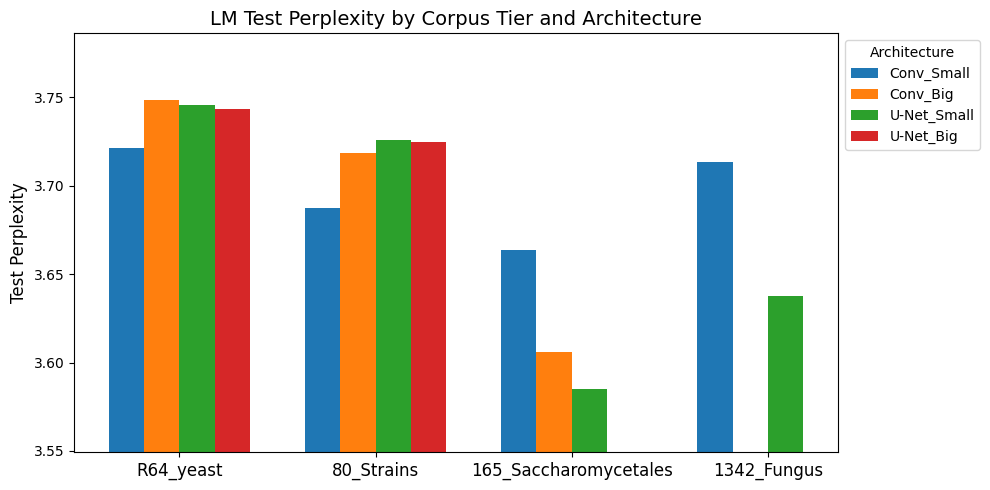

In [5]:
# Figure A: grouped bar chart of overall perplexity by corpus tier x architecture.
n_groups = len(datasets)
n_models = len(model_names)
x = np.arange(n_groups)
bar_width = 0.18

valid = perp_matrix[~np.isnan(perp_matrix)]
lo, hi = (valid.min(), valid.max()) if valid.size else (0.0, 1.0)
ratio = 0.01

fig, ax = plt.subplots(figsize=(10, 5))
for i, model_name in enumerate(model_names):
    offset = (i - (n_models / 2 - 0.5)) * bar_width
    ax.bar(x + offset, perp_matrix[:, i], width=bar_width, label=model_name)

ax.set_xticks(x)
ax.set_xticklabels([dataset_label_map[ds] for ds in datasets], fontsize=12)
ax.set_ylabel("Test Perplexity", fontsize=12)
ax.set_title("LM Test Perplexity by Corpus Tier and Architecture", fontsize=14)
ax.set_ylim([lo * (1 - ratio), hi * (1 + ratio)])
ax.legend(title="Architecture", loc="upper left", bbox_to_anchor=(1, 1), fontsize=10)
plt.tight_layout()
plt.show()

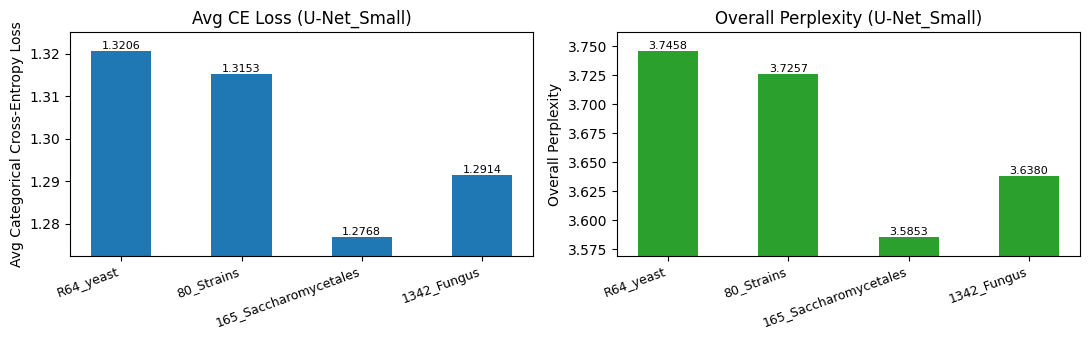

In [6]:
# Figure B: overall avg CE loss and perplexity by corpus tier (representative U-Net_Small).
loss_values = [overall_metrics[ds]["loss"] for ds in datasets]
perp_values = [overall_metrics[ds]["perplexity"] for ds in datasets]
labels = [dataset_label_map[ds] for ds in datasets]
xs = np.arange(len(datasets))

fig, (ax_loss, ax_perp) = plt.subplots(1, 2, figsize=(11, 3.5))

ax_loss.bar(xs, loss_values, width=0.5, color="tab:blue")
ax_loss.set_xticks(xs)
ax_loss.set_xticklabels(labels, fontsize=9, rotation=20, ha="right")
ax_loss.set_ylabel("Avg Categorical Cross-Entropy Loss", fontsize=10)
ax_loss.set_title(f"Avg CE Loss ({representative_arch})", fontsize=12)
lmin, lmax = np.nanmin(loss_values), np.nanmax(loss_values)
ax_loss.set_ylim([lmin - (lmax - lmin) * 0.1, lmax + (lmax - lmin) * 0.1])
for i, v in enumerate(loss_values):
    if v is not None and not np.isnan(v):
        ax_loss.text(i, v, f"{v:.4f}", ha="center", va="bottom", fontsize=8)

ax_perp.bar(xs, perp_values, width=0.5, color="tab:green")
ax_perp.set_xticks(xs)
ax_perp.set_xticklabels(labels, fontsize=9, rotation=20, ha="right")
ax_perp.set_ylabel("Overall Perplexity", fontsize=10)
ax_perp.set_title(f"Overall Perplexity ({representative_arch})", fontsize=12)
pmin, pmax = np.nanmin(perp_values), np.nanmax(perp_values)
ax_perp.set_ylim([pmin - (pmax - pmin) * 0.1, pmax + (pmax - pmin) * 0.1])
for i, v in enumerate(perp_values):
    if v is not None and not np.isnan(v):
        ax_perp.text(i, v, f"{v:.4f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

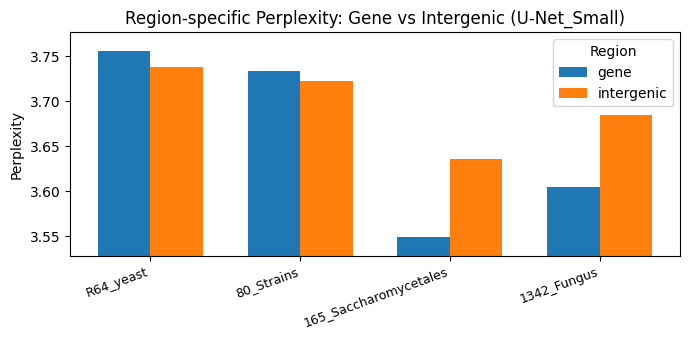

In [7]:
# Figure C: region-specific perplexity (gene vs intergenic) by corpus tier.
desired_order = ["R64_yeast", "80_Strains", "165_Saccharomycetales", "1342_Fungus"]
region_rows = []
for ds in datasets:
    df = region_metrics.get(ds, pd.DataFrame())
    if not df.empty and "region" in df.columns:
        df = df[df["region"].isin(["gene", "intergenic"])].copy()
        if not df.empty:
            df["dataset"] = dataset_label_map[ds]
            region_rows.append(df)

if region_rows:
    combined = pd.concat(region_rows, ignore_index=True)
    pivot_perp = combined.pivot(index="dataset", columns="region", values="perplexity").reindex(desired_order)

    fig, ax = plt.subplots(figsize=(7, 3.5))
    xr = np.arange(len(pivot_perp.index))
    bw = 0.35
    regions = pivot_perp.columns.tolist()
    for i, region in enumerate(regions):
        offset = (i - len(regions) / 2) * bw + bw / 2
        ax.bar(xr + offset, pivot_perp[region], width=bw, label=region)
    ax.set_xticks(xr)
    ax.set_xticklabels(pivot_perp.index, fontsize=9, rotation=20, ha="right")
    ax.set_ylabel("Perplexity", fontsize=10)
    ax.set_title(f"Region-specific Perplexity: Gene vs Intergenic ({representative_arch})", fontsize=12)
    pmn, pmx = np.nanmin(pivot_perp.values), np.nanmax(pivot_perp.values)
    margin = (pmx - pmn) * 0.1 if pmx > pmn else 0.1
    ax.set_ylim([pmn - margin, pmx + margin])
    ax.legend(title="Region")
    plt.tight_layout()
    plt.show()
else:
    print("No region-specific (gene / intergenic) metrics found in the parsed logs.")